# 04 — Thailand District GIS
## Administrative Hierarchy, Spatial Query & Interactive Basemaps

**กลุ่มผู้เรียน:** ปริญญาตรีปี 3–4 และปริญญาโทปี 1–2 สาขาวิทยาศาสตร์สิ่งแวดล้อม  
**ระดับ:** Intermediate  
**ข้อมูล:** Thailand ADM1 Provinces + ADM2 Districts  
**เครื่องมือ:** GeoPandas · Pandas · Matplotlib · Folium · MapClassify · xyzservices

Notebook นี้ต่อจาก Notebook 03 โดยเปลี่ยนจากการวิเคราะห์ polygon ชั้นเดียว ไปสู่ **ความสัมพันธ์ระหว่างหลายชั้นข้อมูล**

$$
\text{Province}
\rightarrow
\text{District}
\rightarrow
\text{Attribute hierarchy}
\rightarrow
\text{Spatial relationship}
\rightarrow
\text{Spatial Join}
\rightarrow
\text{Validation}
\rightarrow
\text{Map}
$$

คำถามหลัก:

> เรารู้จาก attribute ว่าอำเภอหนึ่งอยู่ในจังหวัดใด แต่ GIS สามารถตรวจสอบความสัมพันธ์นั้นจากตำแหน่งของ geometry ได้หรือไม่?

## Learning objectives

เมื่อเรียนจบ Notebook นี้ นิสิตควรสามารถ

1. อธิบาย administrative hierarchy: ADM0 → ADM1 → ADM2 → ADM3
2. ตรวจ identifier และ parent key ของข้อมูลอำเภอ
3. ใช้ `groupby()` นับจำนวนอำเภอต่อจังหวัด
4. Join จำนวนอำเภอกลับเข้าสู่ layer จังหวัด
5. คำนวณพื้นที่อำเภอและหา Top 10
6. Query อำเภอในจังหวัดพิษณุโลกด้วย attribute
7. อธิบาย `within`, `contains`, `intersects`
8. ใช้ `gpd.sjoin()` เพื่อ spatial join ระหว่างอำเภอกับจังหวัด
9. ตรวจ agreement ระหว่าง attribute hierarchy กับ spatial hierarchy
10. สร้างแผนที่อำเภอพิษณุโลกพร้อม labels ภาษาไทย
11. ใช้ Folium แบบ **เปิด/ปิด operational layers**
12. **สลับ basemap** ระหว่าง OpenTopoMap, Esri World Topographic และ Esri World Imagery
13. Export publication maps 300 dpi, GeoPackage, Shapefile, CSV และ HTML

## Recap จาก Notebook 03

Notebook 03 เน้น

$$
\text{Polygon}
+
\text{Attribute}
+
\text{Measurement}
+
\text{Statistics}
+
\text{Thematic Mapping}
$$

Notebook 04 เพิ่มแนวคิดใหม่:

$$
\boxed{
\text{Relationship between layers}
}
$$

จากเดิมที่เราถามว่า

> จังหวัดใดมีพื้นที่มากที่สุด?

ตอนนี้เราจะถามว่า

> อำเภอใดอยู่ในจังหวัดใด และเราพิสูจน์จาก geometry ได้อย่างไร?

## แนวคิด Web GIS ที่จะเพิ่มในบทนี้

Folium map จะประกอบด้วย 2 กลุ่ม layer

```text
Web Map
│
├── Basemap
│   ├── OpenTopoMap
│   ├── Esri World Topographic
│   └── Esri World Imagery
│
└── Operational layers
    ├── Province boundary
    ├── District boundaries
    ├── District area
    ├── Labels
    └── Selected district
```

**Basemap** ใช้เป็นบริบทเพื่อช่วยอ่านตำแหน่ง  
**Operational layer** คือข้อมูลที่เรากำลัง query หรือวิเคราะห์

> Satellite basemap ≠ classification result  
> เห็นสิ่งหนึ่งบน imagery ≠ วัดสิ่งนั้นโดยอัตโนมัติ

## 1. ติดตั้ง libraries

In [1]:
%pip -q install geopandas folium mapclassify xyzservices pyogrio

In [2]:
from pathlib import Path
import shutil
import zipfile

import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import folium
import xyzservices.providers as xyz
import mapclassify

from IPython.display import display

print("GeoPandas  :", gpd.__version__)
print("Pandas     :", pd.__version__)
print("Folium     :", folium.__version__)
print("MapClassify:", mapclassify.__version__)

GeoPandas  : 1.2.0
Pandas     : 2.2.3
Folium     : 0.20.0
MapClassify: 2.10.0


## 2. Font ภาษาไทย — Sarabun

เหมือน Notebook 02–03 เราดาวน์โหลด `.ttf` โดยตรง เพื่อแยกปัญหา **font rendering** ออกจาก **DBF encoding**

In [3]:
FONT_URL = (
    "https://raw.githubusercontent.com/"
    "google/fonts/main/ofl/sarabun/Sarabun-Regular.ttf"
)

FONT_FILE = Path("/content/Sarabun-Regular.ttf")

if not FONT_FILE.exists():
    response = requests.get(FONT_URL, timeout=60)
    response.raise_for_status()
    FONT_FILE.write_bytes(response.content)

mpl.font_manager.fontManager.addfont(str(FONT_FILE))

font_name = mpl.font_manager.FontProperties(
    fname=str(FONT_FILE)
).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

print("Thai font ready:", font_name)

Thai font ready: Sarabun


## 3. Workspace

In [4]:
DATA_DIR = Path("/content/gis04_data")
OUTPUT_DIR = Path("/content/gis04_outputs")

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data folder   :", DATA_DIR)
print("Output folder :", OUTPUT_DIR)

Data folder   : /content/gis04_data
Output folder : /content/gis04_outputs


## 4. Download helper

In [5]:
def download_and_extract_zip(url, zip_name, extract_name):
    zip_path = DATA_DIR / zip_name
    extract_dir = DATA_DIR / extract_name

    if not zip_path.exists():
        response = requests.get(url, timeout=120)
        response.raise_for_status()
        zip_path.write_bytes(response.content)

    if extract_dir.exists():
        shutil.rmtree(extract_dir)

    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

    shp_files = list(extract_dir.rglob("*.shp"))

    if not shp_files:
        raise FileNotFoundError(
            f"ไม่พบ .shp ใน {zip_name}"
        )

    print("ZIP      :", zip_path)
    print("Extracted:", extract_dir)
    print("Shapefile:", shp_files[0])

    return shp_files[0]

## 5. Helper สำหรับค้นหา field จาก schema จริง

เราไม่สมมติชื่อ field โดยไม่ตรวจข้อมูลก่อน

In [6]:
def find_column(gdf, candidates, required=False):
    lookup = {
        str(c).upper(): c
        for c in gdf.columns
    }

    for candidate in candidates:
        if candidate.upper() in lookup:
            return lookup[candidate.upper()]

    if required:
        raise KeyError(
            "ไม่พบ field ที่คาดไว้: "
            + ", ".join(candidates)
            + "\nFields จริง: "
            + ", ".join(map(str, gdf.columns))
        )

    return None

# Part A — Load ADM1 + ADM2

## 6. Download จังหวัด (ADM1)

In [7]:
ADM1_URL = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/"
    "main/tha_adm1/tha_adm1_province_shapefile.zip"
)

adm1_shp = download_and_extract_zip(
    ADM1_URL,
    "tha_adm1_province_shapefile.zip",
    "tha_adm1"
)

ZIP      : /content/gis04_data/tha_adm1_province_shapefile.zip
Extracted: /content/gis04_data/tha_adm1
Shapefile: /content/gis04_data/tha_adm1/tha_adm1_province.shp


## 7. Download อำเภอ (ADM2)

In [8]:
ADM2_URL = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/"
    "main/tha_adm2/tha_admbnda_adm2_shapefile.zip"
)

adm2_shp = download_and_extract_zip(
    ADM2_URL,
    "tha_admbnda_adm2_shapefile.zip",
    "tha_adm2"
)

ZIP      : /content/gis04_data/tha_admbnda_adm2_shapefile.zip
Extracted: /content/gis04_data/tha_adm2
Shapefile: /content/gis04_data/tha_adm2/tha_admbnda_adm2.shp


## 8. อ่าน Shapefile ด้วย UTF-8

ถ้าชื่อไทยกลายเป็น `à¸...` ปัญหาคือ encoding ไม่ใช่ font

In [9]:
province = gpd.read_file(
    adm1_shp,
    encoding="UTF-8"
)

district = gpd.read_file(
    adm2_shp,
    encoding="UTF-8"
)

print("Province features:", len(province))
print("District features:", len(district))

print("\nProvince CRS:", province.crs)
print("District CRS:", district.crs)

Province features: 77
District features: 928

Province CRS: EPSG:4326
District CRS: EPSG:4326


## 9. ตรวจ schema

In [10]:
print("ADM1 columns:")
print(list(province.columns))

print("\nADM2 columns:")
print(list(district.columns))

display(province.head(3))
display(district.head(3))

ADM1 columns:
['Shape_Leng', 'Shape_Area', 'ADM1_EN', 'ADM1_TH', 'ADM1_PCODE', 'ADM1_REF', 'ADM1ALT1EN', 'ADM1ALT2EN', 'ADM1ALT1TH', 'ADM1ALT2TH', 'ADM0_EN', 'ADM0_TH', 'ADM0_PCODE', 'date', 'validOn', 'validTo', 'geometry']

ADM2 columns:
['Shape_Leng', 'Shape_Area', 'ADM2_EN', 'ADM2_TH', 'ADM2_PCODE', 'ADM2_REF', 'ADM2ALT1EN', 'ADM2ALT2EN', 'ADM2ALT1TH', 'ADM2ALT2TH', 'ADM1_EN', 'ADM1_TH', 'ADM1_PCODE', 'ADM0_EN', 'ADM0_TH', 'ADM0_PCODE', 'date', 'validOn', 'validTo', 'geometry']


,Shape_Leng,Shape_Area,ADM1_EN,ADM1_TH,ADM1_PCODE,ADM1_REF,ADM1ALT1EN,ADM1ALT2EN,ADM1ALT1TH,ADM1ALT2TH,ADM0_EN,ADM0_TH,ADM0_PCODE,date,validOn,validTo,geometry
0,2.417227,0.131339,Bangkok,กรุงเทพมหานคร,TH10,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18T00:00:00.000Z,2022-01-22T00:00:00.000Z,1899-11-30T00:00:00.000Z,"POLYGON ((100.91398 13.94655, 100.90848 13.902..."
1,1.695100,0.079262,Samut Prakan,สมุทรปราการ,TH11,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18T00:00:00.000Z,2022-01-22T00:00:00.000Z,1899-11-30T00:00:00.000Z,"POLYGON ((100.86078 13.6969, 100.8774 13.68972..."
2,1.251111,0.053238,Nonthaburi,นนทบุรี,TH12,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18T00:00:00.000Z,2022-01-22T00:00:00.000Z,1899-11-30T00:00:00.000Z,"POLYGON ((100.56748 13.95118, 100.54364 13.849..."


,Shape_Leng,Shape_Area,ADM2_EN,ADM2_TH,ADM2_PCODE,ADM2_REF,ADM2ALT1EN,ADM2ALT2EN,ADM2ALT1TH,ADM2ALT2TH,ADM1_EN,ADM1_TH,ADM1_PCODE,ADM0_EN,ADM0_TH,ADM0_PCODE,date,validOn,validTo,geometry
0,0.085417,0.000450,Phra Nakhon,พระนคร,TH1001,None,None,None,None,None,Bangkok,กรุงเทพมหานคร,TH10,Thailand,ประเทศไทย,TH,2019-02-18T00:00:00.000Z,2022-01-22T00:00:00.000Z,1899-11-30T00:00:00.000Z,"POLYGON ((100.49978 13.73858, 100.49755 13.739..."
1,0.134132,0.000950,Dusit,ดุสิต,TH1002,None,None,None,None,None,Bangkok,กรุงเทพมหานคร,TH10,Thailand,ประเทศไทย,TH,2019-02-18T00:00:00.000Z,2022-01-22T00:00:00.000Z,1899-11-30T00:00:00.000Z,"POLYGON ((100.53738 13.79786, 100.52791 13.774..."
2,0.676342,0.019859,Nong Chok,หนองจอก,TH1003,None,None,None,None,None,Bangkok,กรุงเทพมหานคร,TH10,Thailand,ประเทศไทย,TH,2019-02-18T00:00:00.000Z,2022-01-22T00:00:00.000Z,1899-11-30T00:00:00.000Z,"POLYGON ((100.93096 13.8044, 100.92833 13.8013..."


## 10. หา field สำคัญ

In [11]:
adm1_code = find_column(
    province,
    ["ADM1_PCODE", "ADM1_CODE"],
    required=True
)

adm1_th = find_column(
    province,
    ["ADM1_TH", "NAME_1_TH"],
    required=True
)

adm1_en = find_column(
    province,
    ["ADM1_EN", "NAME_1"],
    required=True
)

d_adm1_code = find_column(
    district,
    ["ADM1_PCODE", "ADM1_CODE"],
    required=True
)

d_adm1_th = find_column(
    district,
    ["ADM1_TH", "NAME_1_TH"],
    required=True
)

adm2_code = find_column(
    district,
    ["ADM2_PCODE", "ADM2_CODE"],
    required=True
)

adm2_th = find_column(
    district,
    ["ADM2_TH", "NAME_2_TH"],
    required=True
)

adm2_en = find_column(
    district,
    ["ADM2_EN", "NAME_2"],
    required=True
)

print("Province code :", adm1_code)
print("Province TH   :", adm1_th)
print("Province EN   :", adm1_en)

print("\nDistrict parent code:", d_adm1_code)
print("District code       :", adm2_code)
print("District TH         :", adm2_th)
print("District EN         :", adm2_en)

Province code : ADM1_PCODE
Province TH   : ADM1_TH
Province EN   : ADM1_EN

District parent code: ADM1_PCODE
District code       : ADM2_PCODE
District TH         : ADM2_TH
District EN         : ADM2_EN


## 11. Geometry QC

In [12]:
qc = pd.DataFrame({
    "Province": [
        len(province),
        province.geometry.isna().sum(),
        province.geometry.is_empty.sum(),
        (~province.is_valid.fillna(False)).sum()
    ],
    "District": [
        len(district),
        district.geometry.isna().sum(),
        district.geometry.is_empty.sum(),
        (~district.is_valid.fillna(False)).sum()
    ]
}, index=[
    "All features",
    "Missing geometry",
    "Empty geometry",
    "Invalid / unavailable"
])

display(qc)

print("\nDistrict geometry types:")
display(district.geom_type.value_counts())

,Province,District
All features,77,928
Missing geometry,0,0
Empty geometry,0,0
Invalid / unavailable,0,1



District geometry types:


,count
Polygon,895
MultiPolygon,33


# Part B — Administrative Hierarchy

## 12. ADM0 → ADM1 → ADM2 → ADM3

```text
Country
  ↓
Province      ADM1
  ↓
District      ADM2
  ↓
Subdistrict   ADM3
```

หนึ่ง record ของ ADM2 มักมีทั้ง

```text
ADM2_PCODE  → รหัสอำเภอ
ADM2_TH     → ชื่ออำเภอ
ADM1_PCODE  → รหัสจังหวัดแม่
ADM1_TH     → ชื่อจังหวัดแม่
```

นี่คือ **attribute hierarchy**

In [13]:
display(
    district[
        [
            d_adm1_code,
            d_adm1_th,
            adm2_code,
            adm2_th,
            adm2_en
        ]
    ].head(15)
)

,ADM1_PCODE,ADM1_TH,ADM2_PCODE,ADM2_TH,ADM2_EN
0,TH10,กรุงเทพมหานคร,TH1001,พระนคร,Phra Nakhon
1,TH10,กรุงเทพมหานคร,TH1002,ดุสิต,Dusit
2,TH10,กรุงเทพมหานคร,TH1003,หนองจอก,Nong Chok
3,TH10,กรุงเทพมหานคร,TH1004,บางรัก,Bang Rak
4,TH10,กรุงเทพมหานคร,TH1005,บางเขน,Bang Khen
5,TH10,กรุงเทพมหานคร,TH1006,บางกะปิ,Bang Kapi
6,TH10,กรุงเทพมหานคร,TH1007,ปทุมวัน,Pathum Wan
7,TH10,กรุงเทพมหานคร,TH1008,ป้อมปราบศัตรูพ่า,Pom Prap Sattru Phai
8,TH10,กรุงเทพมหานคร,TH1009,พระโขนง,Phra Khanong
9,TH10,กรุงเทพมหานคร,TH1010,มีนบุรี,Min Buri


## 13. Unique ID และ Parent ID

In [14]:
id_check = pd.DataFrame({
    "Metric": [
        "District features",
        "Unique district codes",
        "Duplicated district codes",
        "Unique parent province codes"
    ],
    "Value": [
        len(district),
        district[adm2_code].nunique(),
        district[adm2_code].duplicated().sum(),
        district[d_adm1_code].nunique()
    ]
})

display(id_check)

,Metric,Value
0,District features,928
1,Unique district codes,928
2,Duplicated district codes,0
3,Unique parent province codes,77


# Part C — จำนวนอำเภอต่อจังหวัด

## 14. `groupby()` เพื่อสรุปลำดับชั้น

จำนวนอำเภอในจังหวัด $p$ เขียนเชิงแนวคิดได้เป็น

$$
N_p=
\sum_i I(d_i \in p)
$$

โดย $I$ มีค่า 1 เมื่ออำเภอ $i$ อยู่ในจังหวัด $p$

In [15]:
district_count = (
    district
    .groupby(
        [
            d_adm1_code,
            d_adm1_th
        ],
        as_index=False
    )
    .agg(
        district_count=(
            adm2_code,
            "count"
        )
    )
)

district_count = district_count.sort_values(
    "district_count",
    ascending=False
)

display(district_count.head(15))

,ADM1_PCODE,ADM1_TH,district_count
0,TH10,กรุงเทพมหานคร,50
18,TH30,นครราชสีมา,32
28,TH40,ขอนแก่น,26
38,TH50,เชียงใหม่,25
22,TH34,อุบลราชธานี,25
63,TH80,นครศรีธรรมราช,23
19,TH31,บุรีรัมย์,23
21,TH33,ศรีสะเกษ,22
29,TH41,อุดรธานี,20
33,TH45,ร้อยเอ็ด,20


## 15. Top 10 จังหวัดที่มีอำเภอมากที่สุด

In [16]:
top10_province_count = (
    district_count
    .nlargest(
        10,
        "district_count"
    )
    .copy()
)

display(top10_province_count)

,ADM1_PCODE,ADM1_TH,district_count
0,TH10,กรุงเทพมหานคร,50
18,TH30,นครราชสีมา,32
28,TH40,ขอนแก่น,26
38,TH50,เชียงใหม่,25
22,TH34,อุบลราชธานี,25
63,TH80,นครศรีธรรมราช,23
19,TH31,บุรีรัมย์,23
21,TH33,ศรีสะเกษ,22
29,TH41,อุดรธานี,20
33,TH45,ร้อยเอ็ด,20


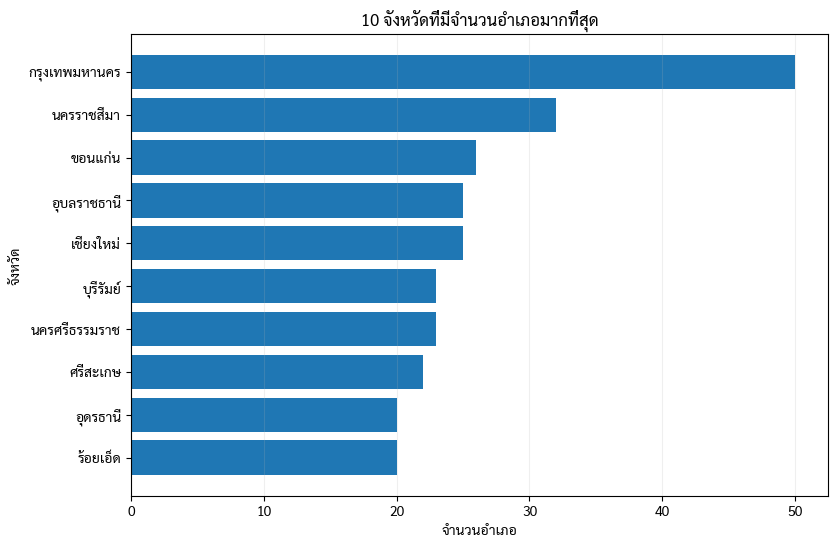

In [17]:
plot_count = top10_province_count.sort_values(
    "district_count",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    plot_count[d_adm1_th],
    plot_count["district_count"]
)

ax.set_title(
    "10 จังหวัดที่มีจำนวนอำเภอมากที่สุด"
)
ax.set_xlabel("จำนวนอำเภอ")
ax.set_ylabel("จังหวัด")
ax.grid(axis="x", alpha=0.2)

plt.show()

### Interpretation

อย่าสรุปว่า

```text
จำนวนอำเภอมาก
=
จังหวัดมีพื้นที่มาก
```

เพราะ administrative subdivision กับ physical area เป็นคนละตัวแปร

# Part D — Join ผลสรุปกลับเข้าสู่ชั้นจังหวัด

## 16. Attribute join ด้วย `ADM1_PCODE`

```text
Province geometry
+
District count table
↓
merge by ADM1_PCODE
↓
Province polygons with district_count
```

In [18]:
province_count_map = province.merge(
    district_count[
        [
            d_adm1_code,
            "district_count"
        ]
    ].rename(
        columns={
            d_adm1_code: adm1_code
        }
    ),
    on=adm1_code,
    how="left"
)

print(
    "Missing district_count:",
    province_count_map[
        "district_count"
    ].isna().sum()
)

display(
    province_count_map[
        [
            adm1_th,
            "district_count"
        ]
    ].head(10)
)

Missing district_count: 0


,ADM1_TH,district_count
0,กรุงเทพมหานคร,50
1,สมุทรปราการ,6
2,นนทบุรี,6
3,ปทุมธานี,7
4,พระนครศรีอยุธยา,16
5,อ่างทอง,7
6,ลพบุรี,11
7,สิงห์บุรี,6
8,ชัยนาท,8
9,สระบุรี,13


## 17. Choropleth — จำนวนอำเภอต่อจังหวัด

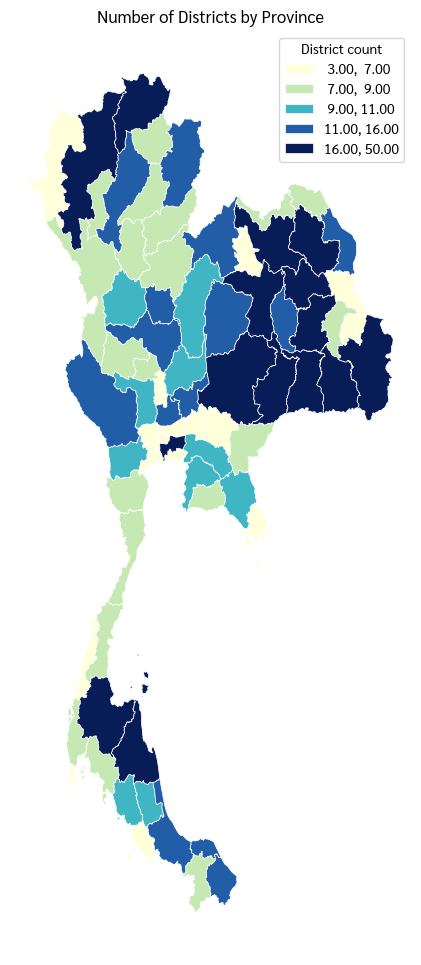

In [19]:
province_count_ea = province_count_map.to_crs(
    "EPSG:6933"
)

fig, ax = plt.subplots(figsize=(8, 12))

province_count_ea.plot(
    ax=ax,
    column="district_count",
    scheme="Quantiles",
    k=5,
    cmap="YlGnBu",
    legend=True,
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={
        "title": "District count"
    }
)

ax.set_title(
    "Number of Districts by Province"
)
ax.set_axis_off()

plt.show()

# Part E — District Area

## 18. คำนวณพื้นที่อำเภอ

สำหรับการเปรียบเทียบอำเภอทั่วประเทศ ใช้ equal-area projection

$$
A_{km^2}
=
\frac{A_{m^2}}{10^6}
$$

In [20]:
district_ea = district.to_crs(
    "EPSG:6933"
)

district_ea["area_km2"] = (
    district_ea.geometry.area
    / 1_000_000
)

display(
    district_ea[
        [
            adm2_th,
            d_adm1_th,
            "area_km2"
        ]
    ].head(10)
)

,ADM2_TH,ADM1_TH,area_km2
0,พระนคร,กรุงเทพมหานคร,5.262493
1,ดุสิต,กรุงเทพมหานคร,11.507168
2,หนองจอก,กรุงเทพมหานคร,237.865104
3,บางรัก,กรุงเทพมหานคร,4.161635
4,บางเขน,กรุงเทพมหานคร,41.032283
5,บางกะปิ,กรุงเทพมหานคร,27.209515
6,ปทุมวัน,กรุงเทพมหานคร,8.075464
7,ป้อมปราบศัตรูพ่า,กรุงเทพมหานคร,2.408859
8,พระโขนง,กรุงเทพมหานคร,13.266889
9,มีนบุรี,กรุงเทพมหานคร,60.280512


## 19. Top 10 อำเภอที่มีพื้นที่มากที่สุด

In [21]:
top10_district_area = (
    district_ea
    .nlargest(
        10,
        "area_km2"
    )
    .copy()
)

top10_district_area["rank"] = range(
    1,
    len(top10_district_area) + 1
)

display(
    top10_district_area[
        [
            "rank",
            adm2_th,
            d_adm1_th,
            "area_km2"
        ]
    ].round(1)
)

,rank,ADM2_TH,ADM1_TH,area_km2
672,1,อุ้มผาง,ตาก,4832.4
731,2,ทองผาภูมิ,กาญจนบุรี,3877.4
651,3,บ้านไร่,อุทัยธานี,3295.5
732,4,สังขละบุรี,กาญจนบุรี,3203.8
728,5,ศรีสวัสดิ์,กาญจนบุรี,3015.0
536,6,อมก๋อย,เชียงใหม่,2852.3
667,7,สามเงา,ตาก,2743.7
521,8,แม่แจ่ม,เชียงใหม่,2733.5
627,9,แม่สะเรียง,แม่ฮ่องสอน,2624.5
726,10,ไทรโยค,กาญจนบุรี,2590.1


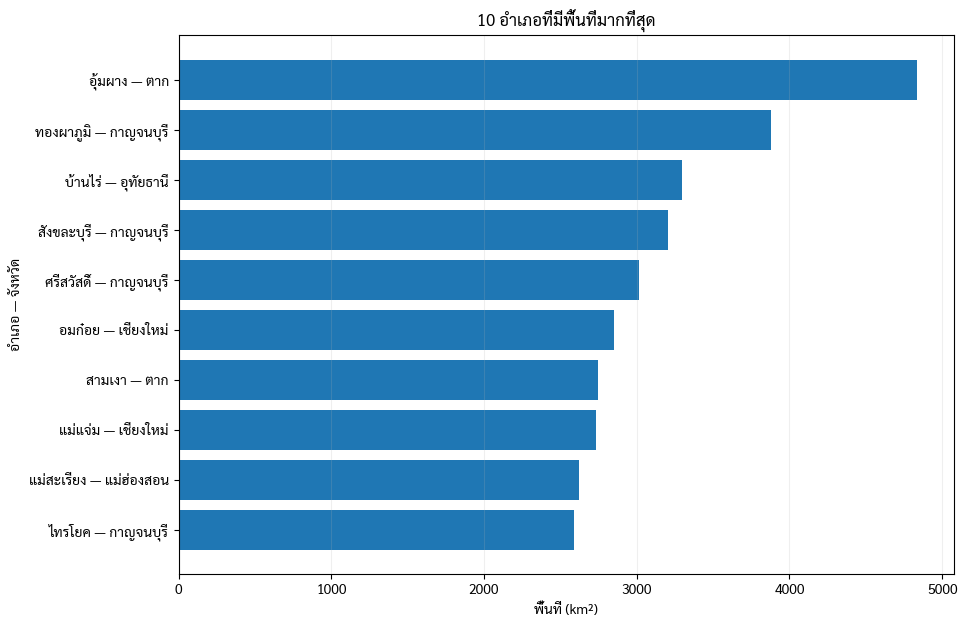

In [22]:
top10_d_plot = top10_district_area.sort_values(
    "area_km2",
    ascending=True
)

labels = (
    top10_d_plot[adm2_th].astype(str)
    + " — "
    + top10_d_plot[d_adm1_th].astype(str)
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    labels,
    top10_d_plot["area_km2"]
)

ax.set_title(
    "10 อำเภอที่มีพื้นที่มากที่สุด"
)
ax.set_xlabel("พื้นที่ (km²)")
ax.set_ylabel("อำเภอ — จังหวัด")
ax.grid(axis="x", alpha=0.2)

plt.show()

## 20. National district-area choropleth

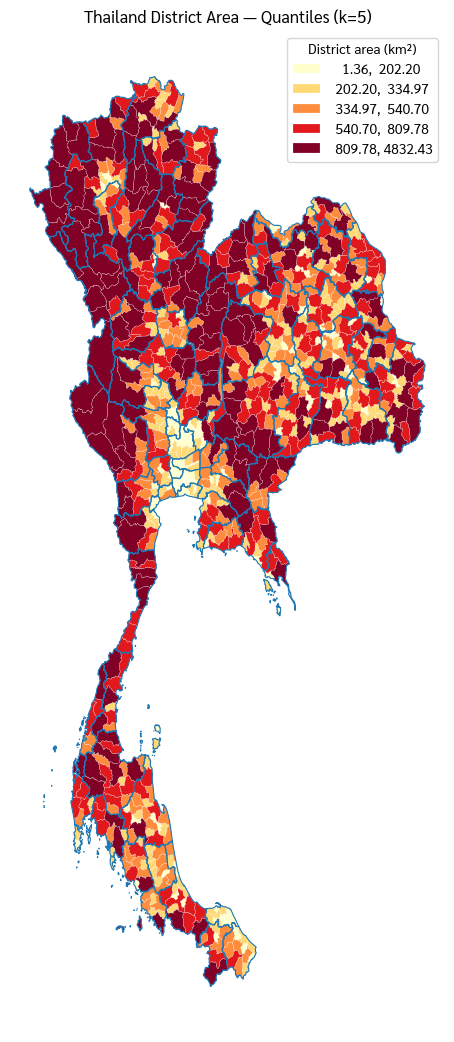

In [23]:
fig, ax = plt.subplots(figsize=(9, 13))

district_ea.plot(
    ax=ax,
    column="area_km2",
    scheme="Quantiles",
    k=5,
    cmap="YlOrRd",
    legend=True,
    edgecolor="white",
    linewidth=0.15,
    legend_kwds={
        "title": "District area (km²)"
    }
)

province_count_ea.boundary.plot(
    ax=ax,
    linewidth=0.8
)

ax.set_title(
    "Thailand District Area — Quantiles (k=5)"
)
ax.set_axis_off()

plt.show()

# Part F — Focus: จังหวัดพิษณุโลก

## 21. Query จังหวัดและอำเภอพิษณุโลกด้วย attribute

In [24]:
phs_province = province[
    province[adm1_th]
    .astype(str)
    .str.contains(
        "พิษณุโลก",
        na=False
    )
].copy()

phs_district = district[
    district[d_adm1_th]
    .astype(str)
    .str.contains(
        "พิษณุโลก",
        na=False
    )
].copy()

print(
    "Province features:",
    len(phs_province)
)

print(
    "District features:",
    len(phs_district)
)

display(
    phs_district[
        [
            adm2_code,
            adm2_th,
            adm2_en,
            d_adm1_th
        ]
    ]
)

Province features: 1
District features: 9


,ADM2_PCODE,ADM2_TH,ADM2_EN,ADM1_TH
683,TH6501,เมืองพิษณุโลก,Mueang Phitsanulok,พิษณุโลก
684,TH6502,นครไทย,Nakhon Thai,พิษณุโลก
685,TH6503,ชาติตระการ,Chat Trakan,พิษณุโลก
686,TH6504,บางระกำ,Bang Rakam,พิษณุโลก
687,TH6505,บางกระทุ่ม,Bang Krathum,พิษณุโลก
688,TH6506,พรหมพิราม,Phrom Phiram,พิษณุโลก
689,TH6507,วัดโบสถ์,Wat Bot,พิษณุโลก
690,TH6508,วังทอง,Wang Thong,พิษณุโลก
691,TH6509,เนินมะปราง,Noen Maprang,พิษณุโลก


## 22. คำนวณพื้นที่อำเภอพิษณุโลกใน UTM Zone 47N

In [25]:
phs_district_utm = phs_district.to_crs(
    "EPSG:32647"
)

phs_province_utm = phs_province.to_crs(
    "EPSG:32647"
)

phs_district_utm["area_km2"] = (
    phs_district_utm.geometry.area
    / 1_000_000
)

phs_area_table = (
    phs_district_utm[
        [
            adm2_code,
            adm2_th,
            adm2_en,
            "area_km2"
        ]
    ]
    .sort_values(
        "area_km2",
        ascending=False
    )
)

display(
    phs_area_table.round(1)
)

,ADM2_PCODE,ADM2_TH,ADM2_EN,area_km2
684,TH6502,นครไทย,Nakhon Thai,2369.0
690,TH6508,วังทอง,Wang Thong,1703.4
685,TH6503,ชาติตระการ,Chat Trakan,1613.5
691,TH6509,เนินมะปราง,Noen Maprang,1110.2
686,TH6504,บางระกำ,Bang Rakam,963.4
689,TH6507,วัดโบสถ์,Wat Bot,864.8
688,TH6506,พรหมพิราม,Phrom Phiram,830.9
683,TH6501,เมืองพิษณุโลก,Mueang Phitsanulok,715.5
687,TH6505,บางกระทุ่ม,Bang Krathum,353.8


## 23. กราฟพื้นที่อำเภอพิษณุโลก

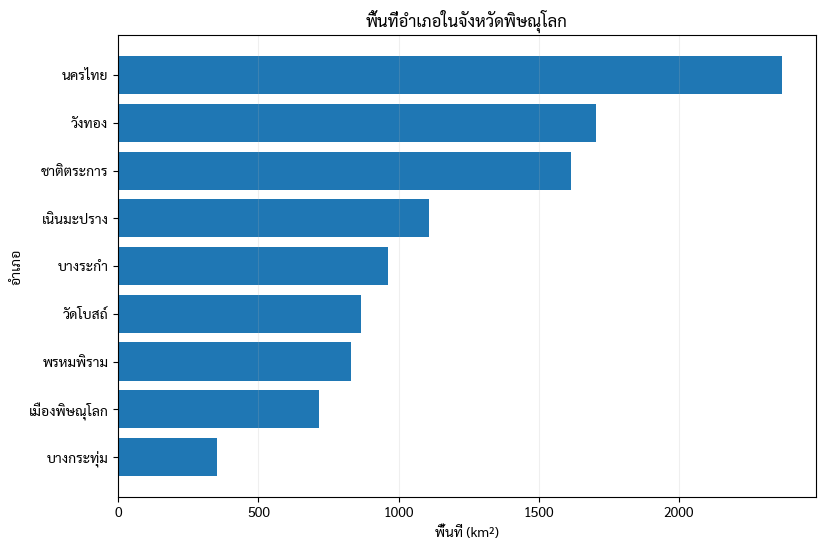

In [26]:
phs_bar = phs_area_table.sort_values(
    "area_km2",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    phs_bar[adm2_th],
    phs_bar["area_km2"]
)

ax.set_title(
    "พื้นที่อำเภอในจังหวัดพิษณุโลก"
)
ax.set_xlabel("พื้นที่ (km²)")
ax.set_ylabel("อำเภอ")
ax.grid(axis="x", alpha=0.2)

plt.show()

## 24. Administrative hierarchy map

หลัก cartography:

```text
Province boundary
→ เส้นหนา

District boundary
→ เส้นบาง
```

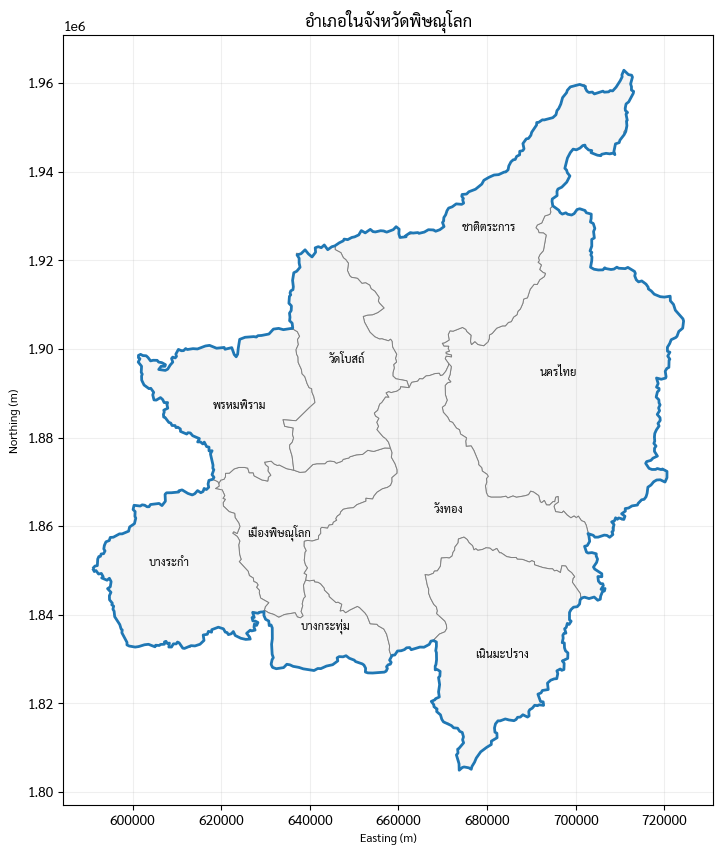

In [27]:
fig, ax = plt.subplots(figsize=(9, 10))

phs_district_utm.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="gray",
    linewidth=0.7
)

phs_province_utm.boundary.plot(
    ax=ax,
    linewidth=2.0
)

label_points = (
    phs_district_utm.geometry
    .representative_point()
)

for idx, pt in label_points.items():
    ax.text(
        pt.x,
        pt.y,
        str(
            phs_district_utm.loc[
                idx,
                adm2_th
            ]
        ),
        fontsize=8,
        ha="center",
        va="center"
    )

ax.set_title(
    "อำเภอในจังหวัดพิษณุโลก"
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.grid(alpha=0.2)

plt.show()

# Part G — Attribute Query vs Spatial Query

## 25. Spatial predicates

### `within`

ถ้า geometry $A$ อยู่ภายใน $B$

$$
A \subset B
$$

### `contains`

ความสัมพันธ์กลับด้าน:

$$
B \supset A
$$

### `intersects`

ถ้ามีส่วนร่วมกัน:

$$
A\cap B\neq\varnothing
$$

คำถามสำคัญ:

> หาก attribute บอกว่าอำเภออยู่พิษณุโลก geometry จะยืนยันเหมือนกันหรือไม่?

## 26. ทำไมใช้ representative point ในการตรวจจังหวัดแม่?

polygon เขตปกครองจากคนละระดับอาจมีเส้นขอบไม่ตรงกัน 100%

ถ้าใช้ polygon `within` โดยตรง อำเภอที่มี boundary ต่างจากจังหวัดเพียงเล็กน้อยอาจไม่ผ่านเงื่อนไข

วิธี teaching ที่ robust:

```text
District polygon
↓
representative_point()
↓
point within province polygon
```

จุด representative อยู่ภายใน district polygon และเหมาะสำหรับถามว่า “district นี้อยู่จังหวัดใด?”

In [28]:
district_points = district[
    [
        adm2_code,
        adm2_th,
        adm2_en,
        d_adm1_code,
        d_adm1_th,
        "geometry"
    ]
].copy()

district_points["geometry"] = (
    district_points.geometry
    .representative_point()
)

district_points = gpd.GeoDataFrame(
    district_points,
    geometry="geometry",
    crs=district.crs
)

district_points.head()

,ADM2_PCODE,ADM2_TH,ADM2_EN,ADM1_PCODE,ADM1_TH,geometry
0,TH1001,พระนคร,Phra Nakhon,TH10,กรุงเทพมหานคร,POINT (100.49661 13.75232)
1,TH1002,ดุสิต,Dusit,TH10,กรุงเทพมหานคร,POINT (100.51655 13.78032)
2,TH1003,หนองจอก,Nong Chok,TH10,กรุงเทพมหานคร,POINT (100.85804 13.84032)
3,TH1004,บางรัก,Bang Rak,TH10,กรุงเทพมหานคร,POINT (100.52649 13.72779)
4,TH1005,บางเขน,Bang Khen,TH10,กรุงเทพมหานคร,POINT (100.63633 13.87179)


## 27. Spatial Join — หา province จากตำแหน่งของ district

In [29]:
province_for_join = province[
    [
        adm1_code,
        adm1_th,
        adm1_en,
        "geometry"
    ]
].copy()

province_for_join = province_for_join.rename(
    columns={
        adm1_code: "SP_ADM1_PCODE",
        adm1_th: "SP_ADM1_TH",
        adm1_en: "SP_ADM1_EN"
    }
)

district_spatial = gpd.sjoin(
    district_points,
    province_for_join,
    how="left",
    predicate="within"
)

display(
    district_spatial[
        [
            adm2_th,
            d_adm1_th,
            "SP_ADM1_TH"
        ]
    ].head(15)
)

,ADM2_TH,ADM1_TH,SP_ADM1_TH
0,พระนคร,กรุงเทพมหานคร,กรุงเทพมหานคร
1,ดุสิต,กรุงเทพมหานคร,กรุงเทพมหานคร
2,หนองจอก,กรุงเทพมหานคร,กรุงเทพมหานคร
3,บางรัก,กรุงเทพมหานคร,กรุงเทพมหานคร
4,บางเขน,กรุงเทพมหานคร,กรุงเทพมหานคร
5,บางกะปิ,กรุงเทพมหานคร,กรุงเทพมหานคร
6,ปทุมวัน,กรุงเทพมหานคร,กรุงเทพมหานคร
7,ป้อมปราบศัตรูพ่า,กรุงเทพมหานคร,กรุงเทพมหานคร
8,พระโขนง,กรุงเทพมหานคร,กรุงเทพมหานคร
9,มีนบุรี,กรุงเทพมหานคร,กรุงเทพมหานคร


## 28. ตรวจ agreement ระหว่าง attribute และ spatial hierarchy

In [30]:
district_spatial["hierarchy_match"] = (
    district_spatial[d_adm1_code]
    .astype(str)
    ==
    district_spatial["SP_ADM1_PCODE"]
    .astype(str)
)

agreement_table = (
    district_spatial[
        "hierarchy_match"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis("Match")
    .reset_index(
        name="Count"
    )
)

display(agreement_table)

match_count = (
    district_spatial[
        "hierarchy_match"
    ].sum()
)

valid_spatial = (
    district_spatial[
        "SP_ADM1_PCODE"
    ].notna().sum()
)

agreement_pct = (
    100 * match_count / valid_spatial
    if valid_spatial > 0
    else np.nan
)

print(
    f"Agreement: {agreement_pct:.2f}%"
)

,Match,Count
0,True,928


Agreement: 100.00%


Agreement:

$$
Agreement(\%)=
\frac{
N_{match}
}{
N_{spatially\ assigned}
}
\times100
$$

ถ้ามี mismatch อย่ารีบสรุปว่า layer ใดผิด  
สาเหตุอาจมาจาก

- attribute error
- geometry mismatch
- boundary generalization
- invalid geometry
- predicate choice

## 29. แสดง records ที่ไม่ match

In [31]:
mismatch = district_spatial[
    ~district_spatial["hierarchy_match"]
    | district_spatial["SP_ADM1_PCODE"].isna()
].copy()

print("Mismatch / unassigned:", len(mismatch))

if len(mismatch) > 0:
    display(
        mismatch[
            [
                adm2_th,
                d_adm1_th,
                "SP_ADM1_TH"
            ]
        ]
    )
else:
    print(
        "Attribute hierarchy and spatial hierarchy agree for all assigned districts."
    )

Mismatch / unassigned: 0
Attribute hierarchy and spatial hierarchy agree for all assigned districts.


# Part H — Query อำเภอเมืองพิษณุโลก

## 30. Query แบบ robust

ชื่อภาษาอังกฤษอาจแตกต่างกันเล็กน้อยระหว่าง datasets  
เราจึงใช้ทั้งชื่อไทยและอังกฤษเป็น fallback

In [32]:
mueang_phs = phs_district_utm[
    phs_district_utm[adm2_th]
    .astype(str)
    .str.contains(
        "เมืองพิษณุโลก",
        na=False
    )
].copy()

if mueang_phs.empty:
    mueang_phs = phs_district_utm[
        phs_district_utm[adm2_en]
        .astype(str)
        .str.contains(
            "Mueang.*Phitsanulok",
            case=False,
            regex=True,
            na=False
        )
    ].copy()

print(
    "Mueang Phitsanulok features:",
    len(mueang_phs)
)

display(
    mueang_phs[
        [
            adm2_code,
            adm2_th,
            adm2_en,
            "area_km2"
        ]
    ]
)

Mueang Phitsanulok features: 1


,ADM2_PCODE,ADM2_TH,ADM2_EN,area_km2
683,TH6501,เมืองพิษณุโลก,Mueang Phitsanulok,715.518459


จุดประสงค์ตอนนี้คือ **query และ highlight polygon**

เรายังไม่ทำ centroid และ buffer เพราะจะเก็บแนวคิดนั้นไว้ Notebook 07

# Part I — Folium: Basemap Switcher + Operational Layers

## 31. Basemap vs Operational Layer

```text
Basemap
→ geographic context

Operational layer
→ data we analyze / query
```

Basemap ในบทนี้:

- OpenTopoMap
- Esri World Topographic
- Esri World Imagery

Operational layers:

- Province boundary
- District boundaries
- District area
- District labels
- Mueang Phitsanulok

> Esri tiles ใช้เพื่อประกอบการตีความเชิงภาพ ควรตรวจเงื่อนไขการใช้งานของผู้ให้บริการสำหรับงานเผยแพร่จริง

## 32. เตรียม layers เป็น EPSG:4326 สำหรับ Folium

In [33]:
phs_province_web = (
    phs_province_utm
    .to_crs("EPSG:4326")
)

phs_district_web = (
    phs_district_utm
    .to_crs("EPSG:4326")
)

mueang_web = (
    mueang_phs
    .to_crs("EPSG:4326")
)

center_pt = (
    phs_province_web.geometry
    .representative_point()
    .iloc[0]
)

print(
    "Map center:",
    center_pt.y,
    center_pt.x
)

Map center: 17.031829109357847 100.5381470650677


## 33. Helper เพิ่มหลาย basemap

In [34]:
def add_basemap(
    m,
    provider,
    name,
    show=False
):
    folium.TileLayer(
        tiles=provider.build_url(),
        attr=provider.html_attribution,
        name=name,
        overlay=False,
        control=True,
        show=show
    ).add_to(m)

## 34. สร้าง map โดยไม่ใช้ default basemap

เหตุผลที่ใช้ `tiles=None` คือเราต้องการควบคุม basemap choices เอง

In [35]:
m = folium.Map(
    location=[
        center_pt.y,
        center_pt.x
    ],
    zoom_start=8,
    tiles=None,
    control_scale=True
)

add_basemap(
    m,
    xyz.OpenTopoMap,
    "OpenTopoMap",
    show=True
)

add_basemap(
    m,
    xyz.Esri.WorldTopoMap,
    "Esri World Topographic",
    show=False
)

add_basemap(
    m,
    xyz.Esri.WorldImagery,
    "Esri World Imagery (Satellite)",
    show=False
)

### ลองสลับ basemap

หลังแสดง map:

```text
Layer Control
→ เลือก OpenTopoMap
→ เลือก Esri World Topographic
→ เลือก Esri World Imagery
```

Basemap เป็น radio buttons จึงเลือกแสดงทีละหนึ่ง layer

## 35. Operational layer — Province boundary

In [36]:
province_group = folium.FeatureGroup(
    name="Province boundary",
    show=True
)

folium.GeoJson(
    phs_province_web,
    style_function=lambda feature: {
        "fillOpacity": 0.0,
        "color": "#000000",
        "weight": 3
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[adm1_th],
        aliases=["จังหวัด:"]
    )
).add_to(province_group)

province_group.add_to(m)

## 36. Operational layer — District boundaries

In [37]:
district_group = folium.FeatureGroup(
    name="District boundaries",
    show=True
)

folium.GeoJson(
    phs_district_web,
    style_function=lambda feature: {
        "fillColor": "#ffffff",
        "fillOpacity": 0.04,
        "color": "#444444",
        "weight": 1.2
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            adm2_th,
            adm2_en,
            "area_km2"
        ],
        aliases=[
            "อำเภอ:",
            "District:",
            "Area (km²):"
        ],
        localize=True
    )
).add_to(district_group)

district_group.add_to(m)

fill opacity ของ district ต่ำมาก เพื่อไม่บัง **Esri World Imagery** เมื่อเปิด satellite basemap

## 37. Operational layer — District area choropleth

In [38]:
folium.Choropleth(
    geo_data=phs_district_web,
    data=phs_district_web,
    columns=[
        adm2_code,
        "area_km2"
    ],
    key_on=f"feature.properties.{adm2_code}",
    fill_color="YlOrRd",
    fill_opacity=0.60,
    line_opacity=0.6,
    legend_name="District area (km²)",
    name="District area choropleth",
    show=False
).add_to(m)

## 38. Operational layer — Labels

In [39]:
label_group = folium.FeatureGroup(
    name="District labels",
    show=False
)

label_web = (
    phs_district_web.geometry
    .representative_point()
)

for idx, pt in label_web.items():
    district_name = str(
        phs_district_web.loc[
            idx,
            adm2_th
        ]
    )

    folium.Marker(
        location=[
            pt.y,
            pt.x
        ],
        icon=folium.DivIcon(
            html=(
                "<div style='"
                "font-size:11px;"
                "font-weight:bold;"
                "color:#111111;"
                "text-shadow:"
                "1px 1px 2px white,"
                "-1px -1px 2px white;"
                "white-space:nowrap;'>"
                f"{district_name}"
                "</div>"
            )
        )
    ).add_to(label_group)

label_group.add_to(m)

## 39. Operational layer — Highlight Mueang Phitsanulok

In [40]:
if not mueang_web.empty:
    folium.GeoJson(
        mueang_web,
        name="Mueang Phitsanulok",
        style_function=lambda feature: {
            "fillColor": "#ff9800",
            "fillOpacity": 0.28,
            "color": "#ff4d00",
            "weight": 3
        },
        tooltip=folium.GeoJsonTooltip(
            fields=[
                adm2_th,
                adm2_en,
                "area_km2"
            ],
            aliases=[
                "อำเภอ:",
                "District:",
                "Area (km²):"
            ],
            localize=True
        )
    ).add_to(m)

## 40. Layer Control

In [41]:
folium.LayerControl(
    collapsed=False
).add_to(m)

m

### ทดลองอ่านภาพดาวเทียม

เปิด **Esri World Imagery** แล้วเปิด/ปิด layer:

- District boundaries
- District labels
- Mueang Phitsanulok

ลองสังเกตเชิงคุณภาพ:

1. พื้นที่เมืองหนาแน่นอยู่บริเวณใด?
2. พื้นที่เกษตรมี pattern อย่างไร?
3. บริเวณภูเขาหรือ terrain สูงอยู่ด้านใด?
4. ขอบเขตอำเภอสอดคล้องกับ landscape feature หรือไม่?

> นี่เป็น **visual interpretation** ไม่ใช่ quantitative land-cover classification

# Part J — Publication-quality Maps

## 41. Helper: North arrow + Scale bar

In [42]:
def add_north_arrow(
    ax,
    x=0.92,
    y=0.10,
    size=0.09
):
    ax.annotate(
        "N",
        xy=(x, y + size),
        xytext=(x, y),
        xycoords=ax.transAxes,
        textcoords=ax.transAxes,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=1.4,
            color="black"
        )
    )


def choose_scale_m(width_m):
    candidates = np.array([
        5_000,
        10_000,
        20_000,
        50_000,
        100_000,
        200_000,
        500_000
    ])

    target = width_m / 4

    return int(
        candidates[
            np.argmin(
                np.abs(
                    candidates - target
                )
            )
        ]
    )


def add_projected_scalebar(ax):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    width_m = xmax - xmin
    height_m = ymax - ymin

    scale_m = choose_scale_m(width_m)

    x0 = xmin + 0.08 * width_m
    y0 = ymin + 0.06 * height_m
    x1 = x0 + scale_m

    ax.plot(
        [x0, x1],
        [y0, y0],
        color="black",
        linewidth=3
    )

    tick = 0.01 * height_m

    ax.plot(
        [x0, x0],
        [y0 - tick, y0 + tick],
        color="black",
        linewidth=1.2
    )

    ax.plot(
        [x1, x1],
        [y0 - tick, y0 + tick],
        color="black",
        linewidth=1.2
    )

    ax.text(
        (x0 + x1) / 2,
        y0 + 0.02 * height_m,
        f"{scale_m/1000:g} km",
        ha="center",
        va="bottom",
        fontsize=8.5
    )

## 42. Publication Map 1 — District Area of Thailand

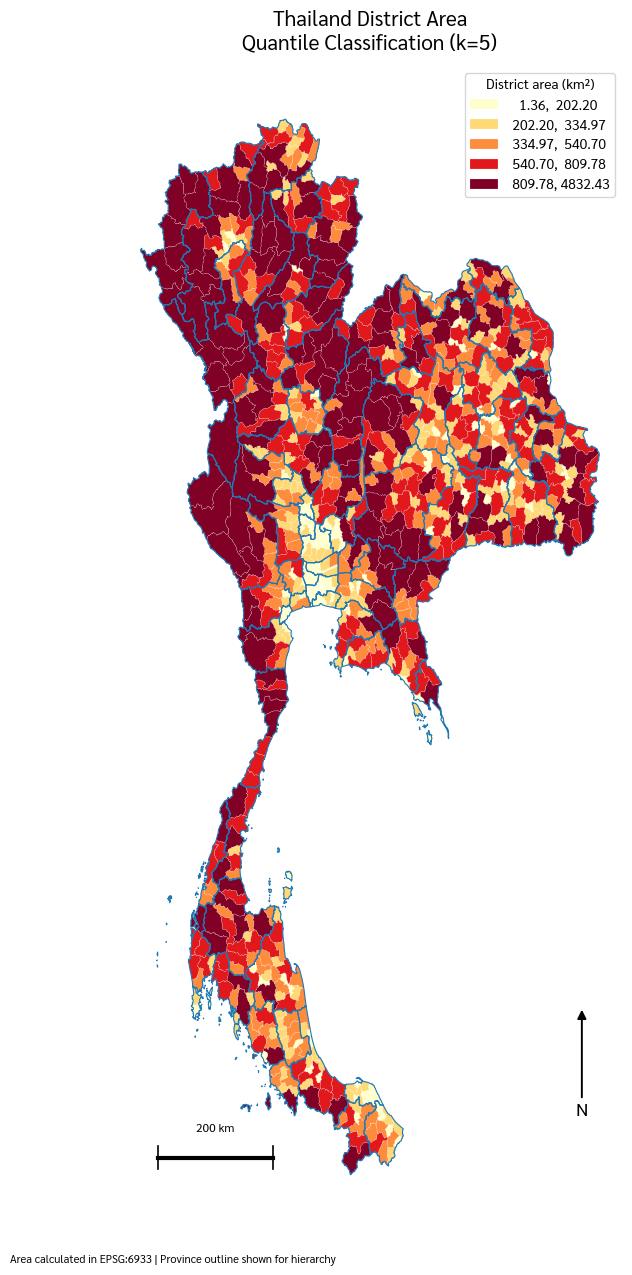

In [43]:
fig_district_area, ax = plt.subplots(
    figsize=(9, 13)
)

district_ea.plot(
    ax=ax,
    column="area_km2",
    scheme="Quantiles",
    k=5,
    cmap="YlOrRd",
    legend=True,
    edgecolor="white",
    linewidth=0.12,
    legend_kwds={
        "title": "District area (km²)"
    }
)

province_count_ea.boundary.plot(
    ax=ax,
    linewidth=0.8
)

ax.set_title(
    "Thailand District Area\n"
    "Quantile Classification (k=5)",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_axis_off()

add_north_arrow(ax)
add_projected_scalebar(ax)

fig_district_area.text(
    0.10,
    0.025,
    "Area calculated in EPSG:6933 | "
    "Province outline shown for hierarchy",
    fontsize=8
)

plt.tight_layout(
    rect=[0, 0.04, 1, 1]
)

plt.show()

## 43. Publication Map 2 — Number of Districts by Province

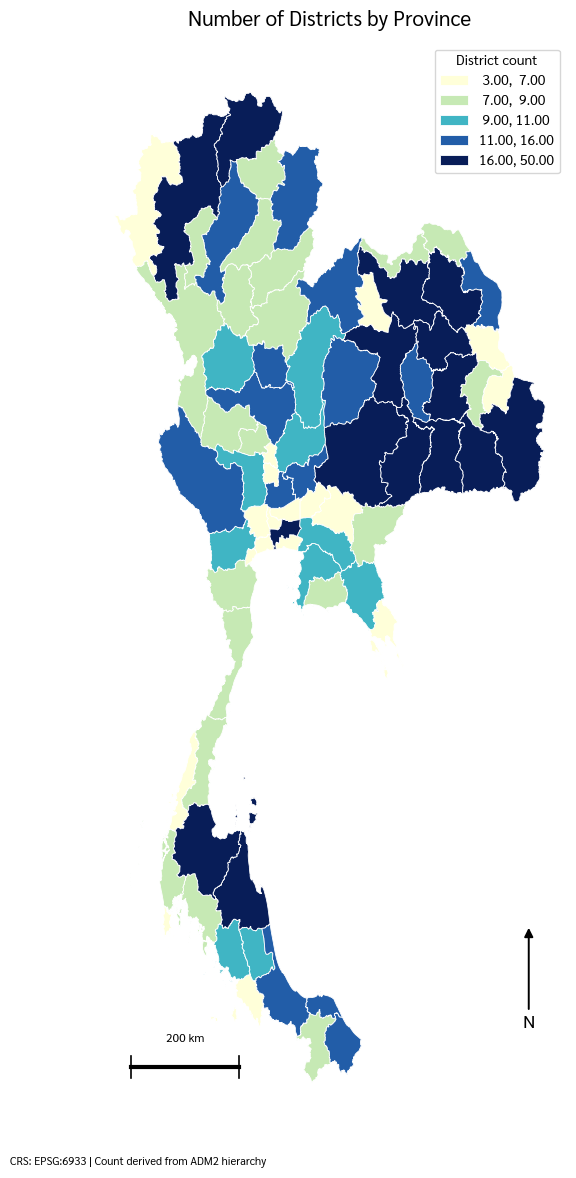

In [44]:
fig_count_map, ax = plt.subplots(
    figsize=(8, 12)
)

province_count_ea.plot(
    ax=ax,
    column="district_count",
    scheme="Quantiles",
    k=5,
    cmap="YlGnBu",
    legend=True,
    edgecolor="white",
    linewidth=0.6,
    legend_kwds={
        "title": "District count"
    }
)

ax.set_title(
    "Number of Districts by Province",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_axis_off()

add_north_arrow(ax)
add_projected_scalebar(ax)

fig_count_map.text(
    0.10,
    0.025,
    "CRS: EPSG:6933 | "
    "Count derived from ADM2 hierarchy",
    fontsize=8
)

plt.tight_layout(
    rect=[0, 0.04, 1, 1]
)

plt.show()

## 44. Publication Map 3 — Districts of Phitsanulok

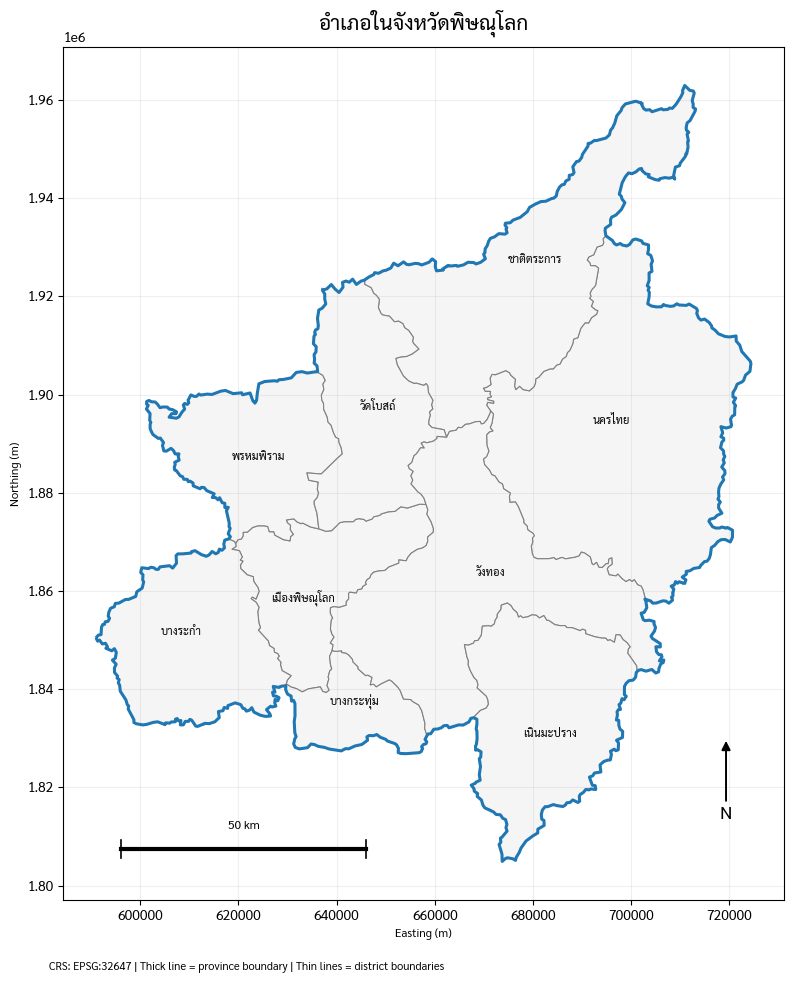

In [45]:
fig_phs, ax = plt.subplots(
    figsize=(9, 10)
)

phs_district_utm.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="gray",
    linewidth=0.8
)

phs_province_utm.boundary.plot(
    ax=ax,
    linewidth=2.2
)

label_points = (
    phs_district_utm.geometry
    .representative_point()
)

for idx, pt in label_points.items():
    ax.text(
        pt.x,
        pt.y,
        str(
            phs_district_utm.loc[
                idx,
                adm2_th
            ]
        ),
        fontsize=8,
        ha="center",
        va="center"
    )

ax.set_title(
    "อำเภอในจังหวัดพิษณุโลก",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.grid(alpha=0.2)

add_north_arrow(ax)
add_projected_scalebar(ax)

fig_phs.text(
    0.10,
    0.025,
    "CRS: EPSG:32647 | "
    "Thick line = province boundary | "
    "Thin lines = district boundaries",
    fontsize=8
)

plt.tight_layout(
    rect=[0, 0.04, 1, 1]
)

plt.show()

## 45. Publication Map 4 — Top 10 Largest Districts

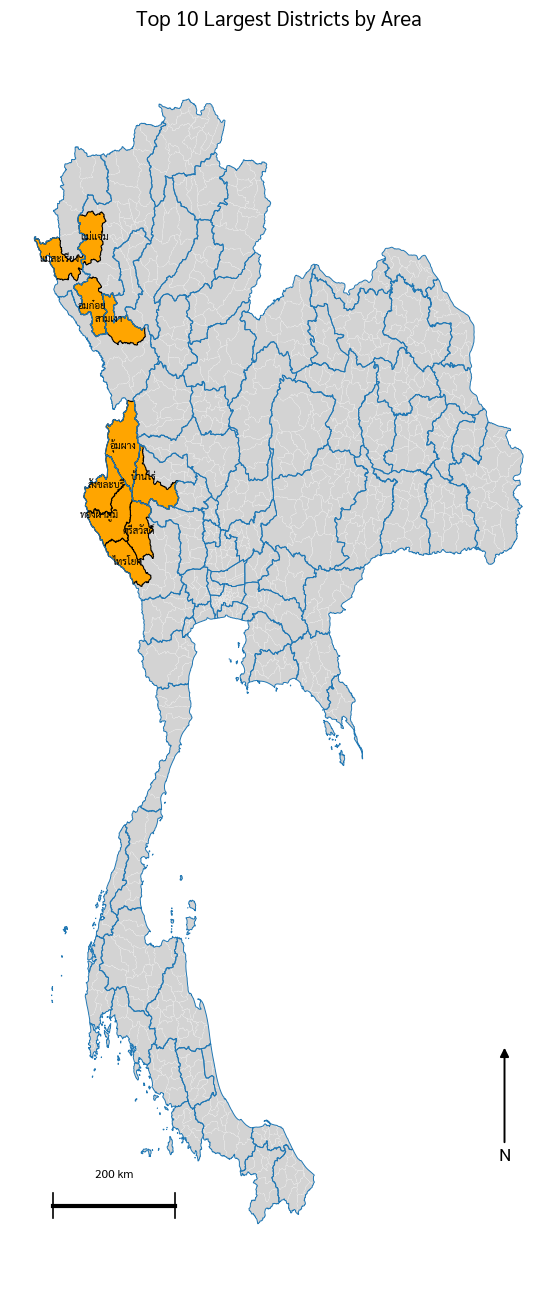

In [46]:
top10_codes = set(
    top10_district_area[
        adm2_code
    ]
)

top10_pub = district_ea[
    district_ea[adm2_code]
    .isin(top10_codes)
].copy()

fig_top10, ax = plt.subplots(
    figsize=(9, 13)
)

district_ea.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="white",
    linewidth=0.1
)

province_count_ea.boundary.plot(
    ax=ax,
    linewidth=0.7
)

top10_pub.plot(
    ax=ax,
    facecolor="orange",
    edgecolor="black",
    linewidth=0.8
)

top10_label = (
    top10_pub.geometry
    .representative_point()
)

for idx, pt in top10_label.items():
    ax.text(
        pt.x,
        pt.y,
        str(
            top10_pub.loc[
                idx,
                adm2_th
            ]
        ),
        fontsize=7,
        ha="center",
        va="center"
    )

ax.set_title(
    "Top 10 Largest Districts by Area",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_axis_off()

add_north_arrow(ax)
add_projected_scalebar(ax)

plt.tight_layout()

plt.show()

# Part K — Export

## 46. Output folders

In [47]:
MAP_DIR = OUTPUT_DIR / "maps"
VECTOR_DIR = OUTPUT_DIR / "vectors"
TABLE_DIR = OUTPUT_DIR / "tables"
HTML_DIR = OUTPUT_DIR / "html"

for folder in [
    MAP_DIR,
    VECTOR_DIR,
    TABLE_DIR,
    HTML_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

## 47. Export PNG 300 dpi

In [48]:
fig_district_area.savefig(
    MAP_DIR / "thailand_district_area_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_count_map.savefig(
    MAP_DIR / "districts_per_province_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_phs.savefig(
    MAP_DIR / "phitsanulok_districts_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_top10.savefig(
    MAP_DIR / "top10_largest_districts_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

print("PNG maps exported.")

PNG maps exported.


## 48. Export GeoPackage

In [49]:
district_gpkg = (
    VECTOR_DIR
    / "thailand_district_analysis.gpkg"
)

if district_gpkg.exists():
    district_gpkg.unlink()

district_ea.to_file(
    district_gpkg,
    layer="district_area",
    driver="GPKG"
)

phs_gpkg = (
    VECTOR_DIR
    / "phitsanulok_districts.gpkg"
)

if phs_gpkg.exists():
    phs_gpkg.unlink()

phs_district_utm.to_file(
    phs_gpkg,
    layer="phitsanulok_districts",
    driver="GPKG"
)

print("Saved:", district_gpkg)
print("Saved:", phs_gpkg)

Saved: /content/gis04_outputs/vectors/thailand_district_analysis.gpkg
Saved: /content/gis04_outputs/vectors/phitsanulok_districts.gpkg


## 49. Export Phitsanulok districts เป็น Shapefile ZIP

In [50]:
shp_folder = (
    VECTOR_DIR
    / "phitsanulok_districts_shp"
)

if shp_folder.exists():
    shutil.rmtree(shp_folder)

shp_folder.mkdir(
    parents=True,
    exist_ok=True
)

shp_out = (
    shp_folder
    / "phitsanulok_districts.shp"
)

phs_export = phs_district_utm[
    [
        adm2_code,
        adm2_en,
        adm2_th,
        d_adm1_code,
        d_adm1_th,
        "area_km2",
        "geometry"
    ]
].copy()

phs_export.to_file(
    shp_out,
    driver="ESRI Shapefile",
    encoding="UTF-8"
)

phs_zip = shutil.make_archive(
    str(
        VECTOR_DIR
        / "phitsanulok_districts"
    ),
    "zip",
    root_dir=shp_folder
)

print("Saved:", phs_zip)

Saved: /content/gis04_outputs/vectors/phitsanulok_districts.zip


## 50. Export CSV tables

In [51]:
district_count.to_csv(
    TABLE_DIR / "district_count_by_province.csv",
    index=False,
    encoding="utf-8-sig"
)

district_rank = (
    district_ea[
        [
            adm2_code,
            adm2_th,
            adm2_en,
            d_adm1_code,
            d_adm1_th,
            "area_km2"
        ]
    ]
    .sort_values(
        "area_km2",
        ascending=False
    )
    .reset_index(drop=True)
)

district_rank["rank"] = (
    district_rank.index + 1
)

district_rank.to_csv(
    TABLE_DIR / "district_area_rank.csv",
    index=False,
    encoding="utf-8-sig"
)

phs_area_table.to_csv(
    TABLE_DIR / "phitsanulok_district_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("CSV tables exported.")

CSV tables exported.


## 51. Export Folium HTML

In [52]:
html_path = (
    HTML_DIR
    / "phitsanulok_district_interactive.html"
)

m.save(html_path)

print("Saved:", html_path)

Saved: /content/gis04_outputs/html/phitsanulok_district_interactive.html


## 52. ตรวจ outputs

In [53]:
for p in sorted(
    OUTPUT_DIR.rglob("*")
):
    if p.is_file():
        print(
            p.relative_to(
                OUTPUT_DIR
            ),
            f"({p.stat().st_size/1024:,.1f} KB)"
        )

html/phitsanulok_district_interactive.html (225.7 KB)
maps/districts_per_province_300dpi.png (478.8 KB)
maps/phitsanulok_districts_300dpi.png (418.1 KB)
maps/thailand_district_area_300dpi.png (1,175.3 KB)
maps/top10_largest_districts_300dpi.png (1,028.5 KB)
tables/district_area_rank.csv (86.5 KB)
tables/district_count_by_province.csv (2.4 KB)
tables/phitsanulok_district_summary.csv (0.6 KB)
vectors/phitsanulok_districts.gpkg (132.0 KB)
vectors/phitsanulok_districts.zip (19.0 KB)
vectors/phitsanulok_districts_shp/phitsanulok_districts.cpg (0.0 KB)
vectors/phitsanulok_districts_shp/phitsanulok_districts.dbf (4.0 KB)
vectors/phitsanulok_districts_shp/phitsanulok_districts.prj (0.4 KB)
vectors/phitsanulok_districts_shp/phitsanulok_districts.shp (25.6 KB)
vectors/phitsanulok_districts_shp/phitsanulok_districts.shx (0.2 KB)
vectors/thailand_district_analysis.gpkg (2,656.0 KB)


# Concept Check

ลองตอบโดยไม่ย้อนดู code

1. ADM1 และ ADM2 ต่างกันอย่างไร?
2. `ADM2_PCODE` และ `ADM1_PCODE` ทำหน้าที่ต่างกันอย่างไร?
3. `groupby()` ช่วยตอบคำถามอะไร?
4. Attribute join ต่างจาก spatial join อย่างไร?
5. `within`, `contains`, `intersects` ต่างกันอย่างไร?
6. ทำไมเราใช้ representative point ในการตรวจ district → province?
7. District count ต่างจาก province area อย่างไร?
8. Basemap ต่างจาก operational layer อย่างไร?
9. ทำไม district polygon บน satellite imagery จึงใช้ fill opacity ต่ำ?
10. Esri World Imagery เป็นข้อมูลวิเคราะห์ land cover โดยอัตโนมัติหรือไม่?

# Exercise 1 — Top 10 จังหวัดที่มีอำเภอมากที่สุด

สร้างผลลัพธ์ด้วยตนเอง:

```text
groupby ADM1
↓
district count
↓
top 10
↓
bar chart
↓
province choropleth
```

เขียน interpretation 2–3 ประโยค

# Exercise 2 — Top 10 อำเภอพื้นที่มากที่สุด

ใช้ `district_ea` แล้ว

1. หา Top 10
2. สร้าง bar chart
3. highlight บนแผนที่ประเทศไทย
4. ตรวจว่ากระจุกอยู่ในจังหวัดหรือภูมิภาคใดเป็นพิเศษหรือไม่

# Exercise 3 — เปลี่ยนจังหวัดศึกษา

เลือกจังหวัดอื่น เช่น

```text
เชียงใหม่
นครราชสีมา
สุราษฎร์ธานี
```

แล้วทำ

```text
Query ADM1
↓
Query ADM2
↓
Calculate district areas
↓
District map with Thai labels
↓
Folium
↓
Export GeoPackage
```

# Exercise 4 — Attribute Query vs Spatial Query

สำหรับจังหวัดที่เลือก:

1. เลือกอำเภอจาก `ADM1_PCODE`
2. เลือกอำเภอจาก spatial join
3. เปรียบเทียบจำนวน
4. ตรวจ features ที่ไม่ตรงกัน
5. อธิบายสาเหตุที่เป็นไปได้

# Exercise 5 — Visual Interpretation with Esri World Imagery

ใน Folium:

1. เปลี่ยน basemap เป็น **Esri World Imagery**
2. เปิด `District boundaries`
3. เปิด `District labels`
4. ปิด/เปิด `District area choropleth`
5. Zoom ไปยังอำเภอเมืองพิษณุโลก

สังเกต:

- urban pattern
- agricultural pattern
- mountains / terrain
- rivers
- relationship between administrative boundaries and landscape

เขียนคำอธิบายประมาณ 5–8 บรรทัด

> อย่าตีความ visual observation เป็น quantitative classification

# MSc Challenge — Hierarchy QA/QC

ใช้ผล spatial join ตรวจว่า

```text
ADM1_PCODE from ADM2 attribute
```

ตรงกับ

```text
ADM1_PCODE assigned by spatial relationship
```

หรือไม่

คำนวณ

$$
Agreement(\%)=
\frac{
N_{match}
}{
N_{spatially\ assigned}
}
\times100
$$

ถ้ามี mismatch ให้ตรวจอย่างเป็นระบบว่าอาจเกิดจาก

- attribute inconsistency
- topology
- boundary mismatch
- geometry validity
- representative point location
- spatial predicate

เป้าหมายคือเรียนว่า **spatial join สามารถใช้เป็นเครื่องมือ QA/QC ได้ ไม่ได้มีไว้เพียงเพิ่ม columns**

# Summary

Notebook 04 เพิ่มแนวคิด GIS สำคัญจาก “ข้อมูลชั้นเดียว” ไปสู่ “ความสัมพันธ์ระหว่างชั้นข้อมูล”

$$
\boxed{
\text{Hierarchy}
+
\text{GroupBy}
+
\text{Spatial Predicate}
+
\text{Spatial Join}
+
\text{Validation}
}
$$

และเพิ่มแนวคิด Web GIS:

$$
\boxed{
Web\ Map
=
Basemap
+
Operational\ Layers
}
$$

สิ่งที่ต้องจำ:

> **Attribute relationship ≠ Spatial relationship**

> **Basemap ≠ Analytical data**

> **Spatial join can also be a QA/QC tool**

> **Satellite imagery helps interpretation, but visual interpretation is not automatic classification**

## ต่อไป: Notebook 05

**Thailand Tambon GIS — Detailed Polygon Analysis & Local Choropleth**

คำถามเปิดบทถัดไป:

> เมื่อเราเพิ่มรายละเอียดจากอำเภอเป็นตำบล จำนวน polygon เพิ่มขึ้นมาก เราจะ query, summarize และสื่อสารข้อมูลให้ชัดเจนโดยไม่ทำให้แผนที่รกได้อย่างไร?